# Generalized energy conservation by step size

For a time-dependent Hamiltonian, the conserved quantity is the extended energy $K(t)=H(t,z(t))+k(t)$, where $\dot{k}=-\partial_t H$. This experiment compares its relative error for `step = 0.005`, `0.001`, and `0.0002`.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from classes import GridPotential, TrajectoryGC, create_system
from config_logging import configure_logging
from workflows.potentials import mock_potential

configure_logging()

potential: GridPotential = mock_potential(
    A=0.7, M=25, nx=64, ny=64, seed=27, k=5,
)
trajectory = TrajectoryGC(rho=0.3, eta=0.0)

2026-07-15 22:34:26 | INFO     | MainProcess | workflows.potentials | Generating mock potential: A=0.7 M=25 grid=64x64 seed=27 interpolation_order=5
2026-07-15 22:34:26 | INFO     | MainProcess | workflows.potentials | Mock potential ready: modes=1 spatial_period=6.28319


In [5]:
# A single trajectory located at the center of the domain.
x0 = 0.5 * (potential.grid.xmin + potential.grid.xmax)
y0 = 0.5 * (potential.grid.ymin + potential.grid.ymax)
z0 = np.array([x0, y0])
trajectory.set_initial_state(z0)
gc_system = create_system(potential, trajectory)

steps = (0.004, 0.001, 0.00025, 625e-05)
t_span = (0.0, 6 * np.pi)
n_output_samples = 361

z0

array([3.09250527, 3.09250527])

In [6]:
solutions = {}
generalized_energies = {}
relative_errors = {}

for integration_step in steps:
    solution = gc_system.simulate(
        step=integration_step,
        t_span=t_span,
        n_output_samples=n_output_samples,
        method='BM4',
        check_energy=True,
        progress=True,
    )

    hamiltonian = np.asarray(gc_system.hamiltonian(solution.t, solution.y))[0]
    generalized_energy = hamiltonian + np.asarray(solution.k)[0]
    energy_scale = max(abs(generalized_energy[0]), np.finfo(float).eps)
    relative_error = (generalized_energy - generalized_energy[0]) / energy_scale

    solutions[integration_step] = solution
    generalized_energies[integration_step] = generalized_energy
    relative_errors[integration_step] = relative_error

print(f"{'step':>10} {'n_steps':>12} {'sol.err':>16} {'max |relative error|':>20}")
for integration_step in steps:
    solution = solutions[integration_step]
    max_error = np.max(np.abs(relative_errors[integration_step]))
    print(
        f"{integration_step:10.4g} {solution.n_steps:12d} "
        f"{solution.err:16.8e} {max_error:20.8e}"
    )

solve_extended [==============================] 100.0% (5040/5040 steps, t=18.8496)
solve_extended [==============================] 100.0% (19080/19080 steps, t=18.8496)
solve_extended [==============================] 100.0% (75600/75600 steps, t=18.8496)
solve_extended [==============================] 100.0% (3240/3240 steps, t=18.8496)


      step      n_steps          sol.err max |relative error|
     0.004         5040   2.27484698e-13       7.16446713e-13
     0.001        19080   7.50677298e-13       2.36420422e-12
   0.00025        75600   2.87520008e-12       9.05523609e-12
   0.00625         3240   1.30978561e-12       4.12507569e-12


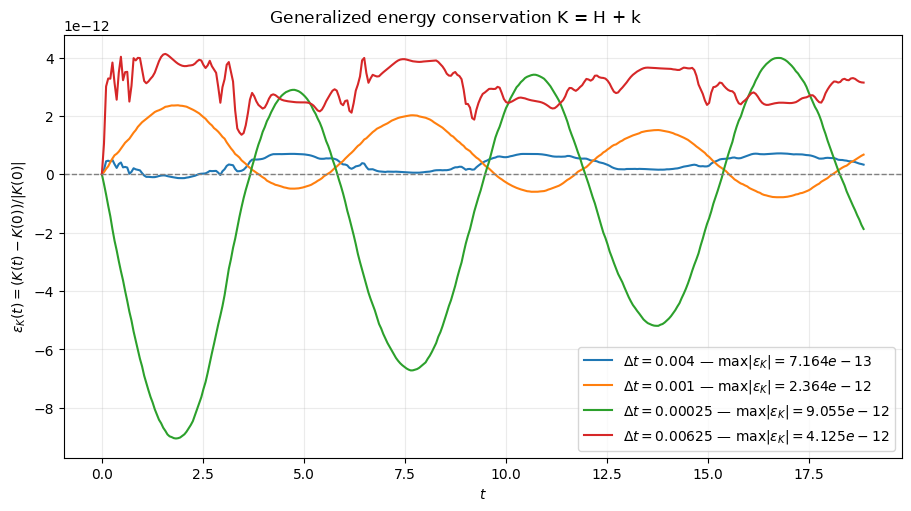

In [7]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

for integration_step in steps:
    solution = solutions[integration_step]
    error = relative_errors[integration_step]
    max_error = np.max(np.abs(error))
    ax.plot(
        solution.t,
        error,
        label=(
            fr'$\Delta t={integration_step:g}$'
            fr' — $\max|\varepsilon_K|={max_error:.3e}$'
        ),
    )

ax.axhline(0.0, color='0.5', ls='--', lw=1)
ax.set(
    xlabel='$t$',
    ylabel=r'$\varepsilon_K(t)=(K(t)-K(0))/|K(0)|$',
    title=r'Generalized energy conservation $K=H+k$',
)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.grid(alpha=0.25)
ax.legend()
plt.show()